In [1]:
!pip -q install transformers accelerate timm
!pip -q install opencv-python pillow matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: C:\Users\ASUS VIVOBOOK\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: C:\Users\ASUS VIVOBOOK\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
from transformers import AutoImageProcessor
from transformers import SegformerForSemanticSegmentation

processor = AutoImageProcessor.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512"
)

model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b2-finetuned-ade-512-512"
)

print("SegFormer Loaded Successfully!")

C:\Users\ASUS VIVOBOOK\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 380/380 [00:00<00:00, 9146.46it/s]

SegFormer Loaded Successfully!


In [ ]:
print(processor)
print(model)

SegformerImageProcessor {
  "do_normalize": true,
  "do_reduce_labels": false,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "SegformerImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "reduce_labels": true,
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 512,
    "width": 512
  }
}

SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (stages): ModuleList(
      (0): SegformerStage(
        (patch_embeddings): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (blocks): ModuleList(
          (0): SegformerLayer(
            (layernorm_before): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (attention): SegformerAttention(
              (q_proj): Linear(in_feat

Saving room.jpg to room.jpg
Original Size: (5633, 3726)


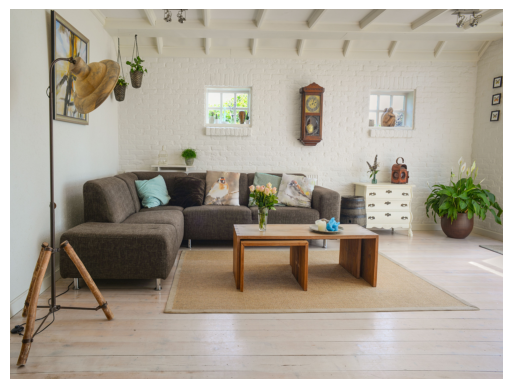

In [ ]:
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

original_image = Image.open(image_path).convert("RGB")

print("Original Size:", original_image.size)

# Resize for inference
image = original_image.resize((1024, 768))

plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
import torch

inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

segmentation = processor.post_process_semantic_segmentation(
    outputs,
    target_sizes=[image.size[::-1]]
)[0]

print(segmentation.shape)

torch.Size([768, 1024])


In [ ]:
for idx, label in model.config.id2label.items():
    if "floor" in label.lower():
        print(idx, label)

3 floor


In [ ]:
FLOOR_ID = 3

floor_mask = (segmentation == FLOOR_ID)

print("Floor Mask Shape:", floor_mask.shape)
print("Floor Pixels:", floor_mask.sum())

Floor Mask Shape: torch.Size([768, 1024])
Floor Pixels: tensor(184671)


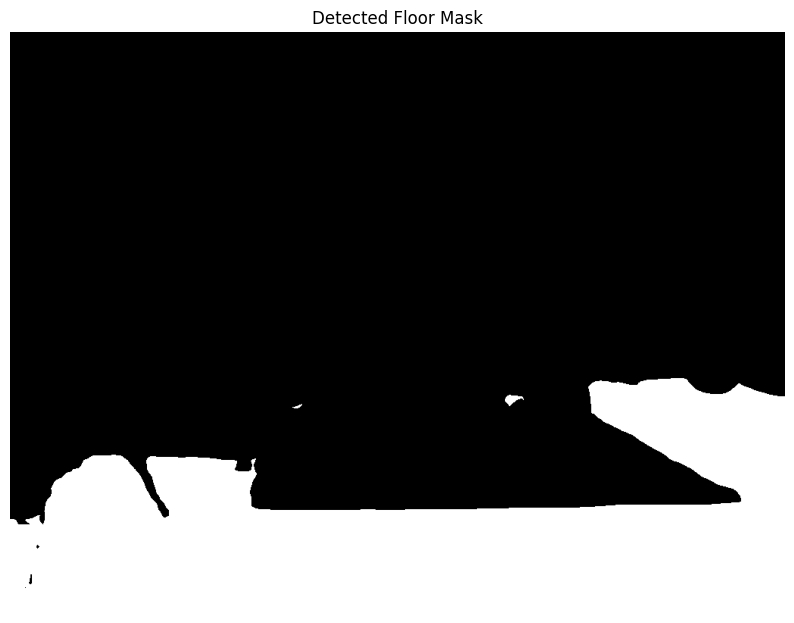

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(floor_mask.cpu().numpy(), cmap="gray")
plt.title("Detected Floor Mask")
plt.axis("off")
plt.show()

In [ ]:
import cv2
import numpy as np

mask = floor_mask.cpu().numpy().astype(np.uint8)

mask = cv2.resize(
    mask,
    original_image.size,
    interpolation=cv2.INTER_NEAREST
)

floor_mask = mask.astype(bool)

print(floor_mask.shape)

(3726, 5633)


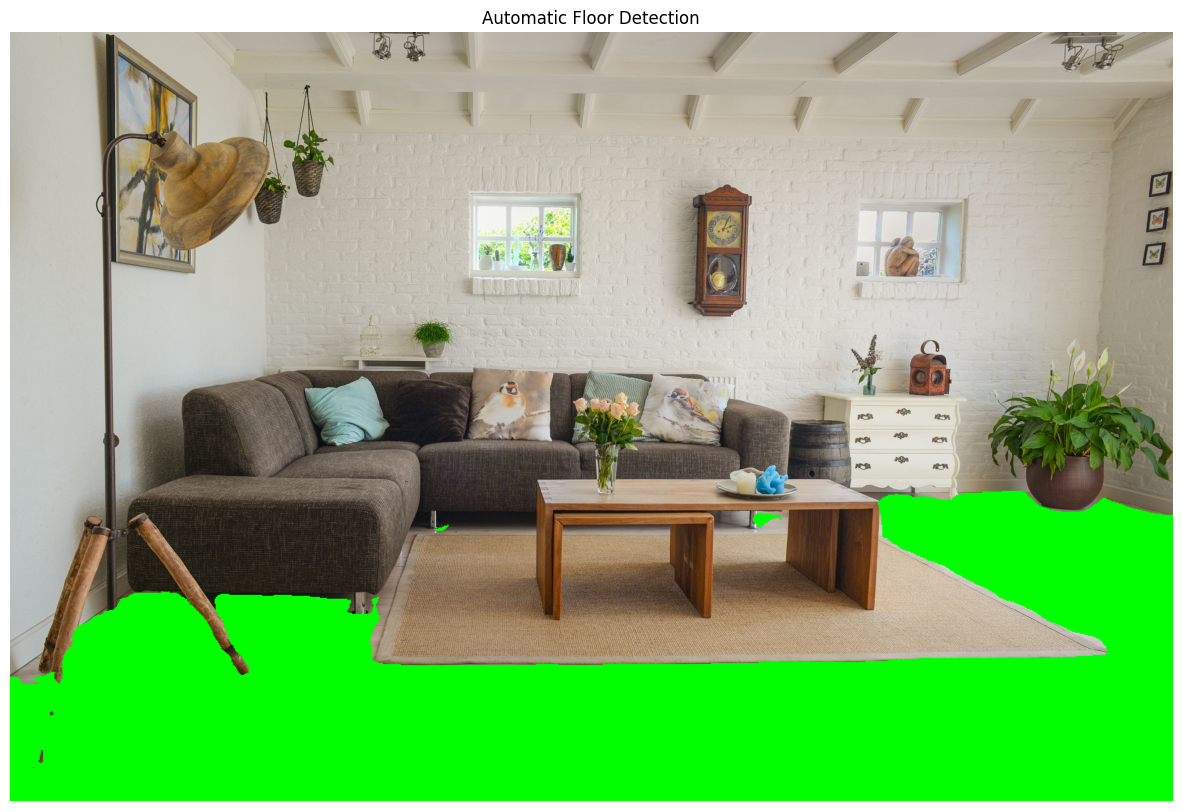

In [ ]:
img = np.array(original_image)

overlay = img.copy()

overlay[floor_mask] = [0,255,0]

plt.figure(figsize=(15,10))
plt.imshow(overlay)
plt.title("Automatic Floor Detection")
plt.axis("off")
plt.show()

Saving tiles.jpg to tiles.jpg


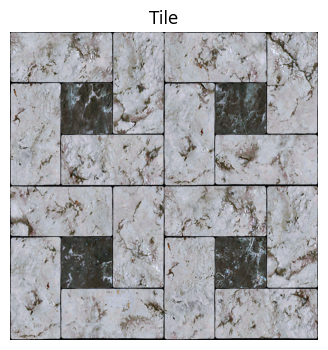

In [ ]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

uploaded = files.upload()

tile_path = list(uploaded.keys())[0]

tile = Image.open(tile_path).convert("RGB")

plt.figure(figsize=(4,4))
plt.imshow(tile)
plt.title("Tile")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np
import cv2

tile = np.array(tile)

H, W = original_image.size[1], original_image.size[0]

tile_h, tile_w = tile.shape[:2]

pattern = np.zeros((H, W, 3), dtype=np.uint8)

for y in range(0, H, tile_h):
    for x in range(0, W, tile_w):
        pattern[y:y+tile_h, x:x+tile_w] = tile[:min(tile_h, H-y), :min(tile_w, W-x)]

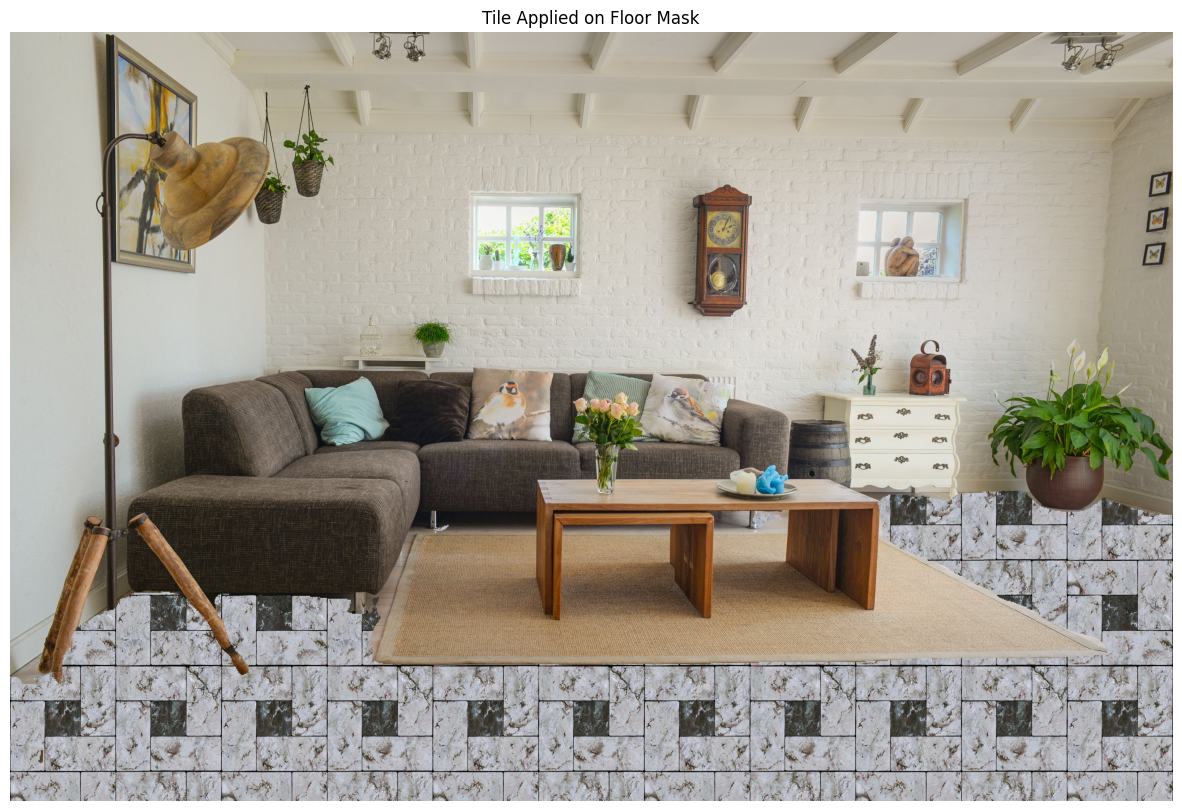

In [ ]:
room = np.array(original_image)

result = room.copy()

result[floor_mask] = pattern[floor_mask]

plt.figure(figsize=(15,10))
plt.imshow(result)
plt.title("Tile Applied on Floor Mask")
plt.axis("off")
plt.show()

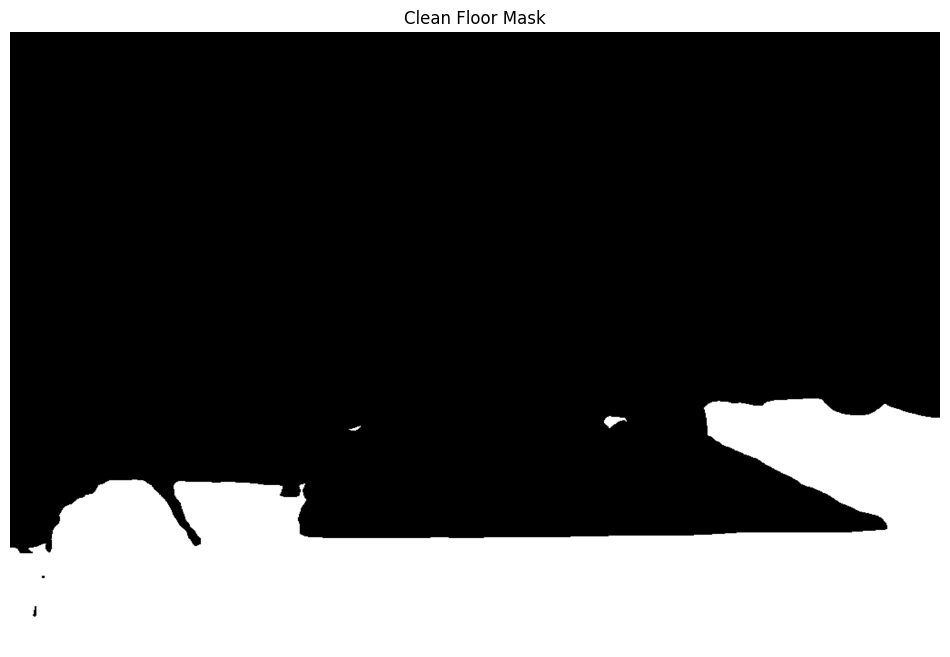

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convert boolean mask to uint8
mask = floor_mask.astype(np.uint8) * 255

# Remove tiny holes
kernel = np.ones((7,7), np.uint8)

mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(12,8))
plt.imshow(mask, cmap='gray')
plt.title("Clean Floor Mask")
plt.axis("off")
plt.show()

In [ ]:
contours, _ = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_NONE
)

largest = max(contours, key=cv2.contourArea)

print("Contour Points :", len(largest))

Contour Points : 18740


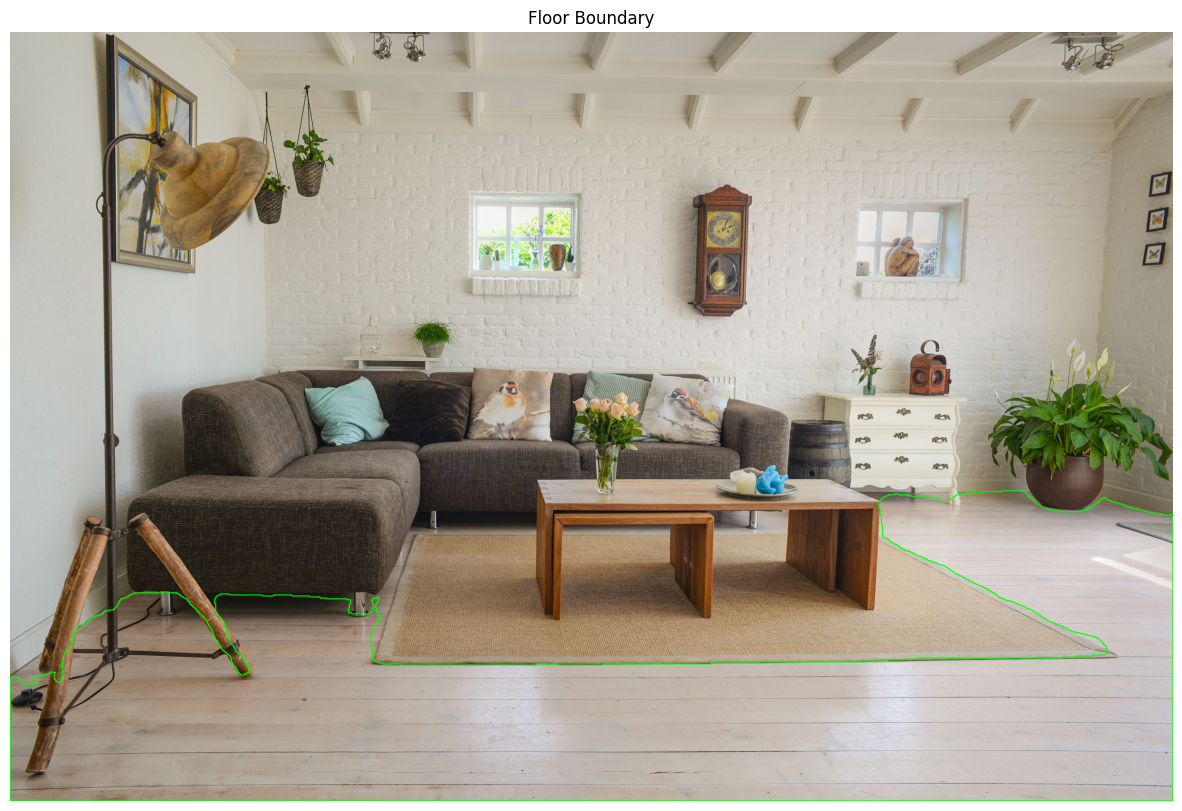

In [ ]:
boundary = image.copy()

cv2.drawContours(
    boundary,
    [largest],
    -1,
    (0,255,0),
    3
)

plt.figure(figsize=(15,10))
plt.imshow(boundary)
plt.title("Floor Boundary")
plt.axis("off")
plt.show()

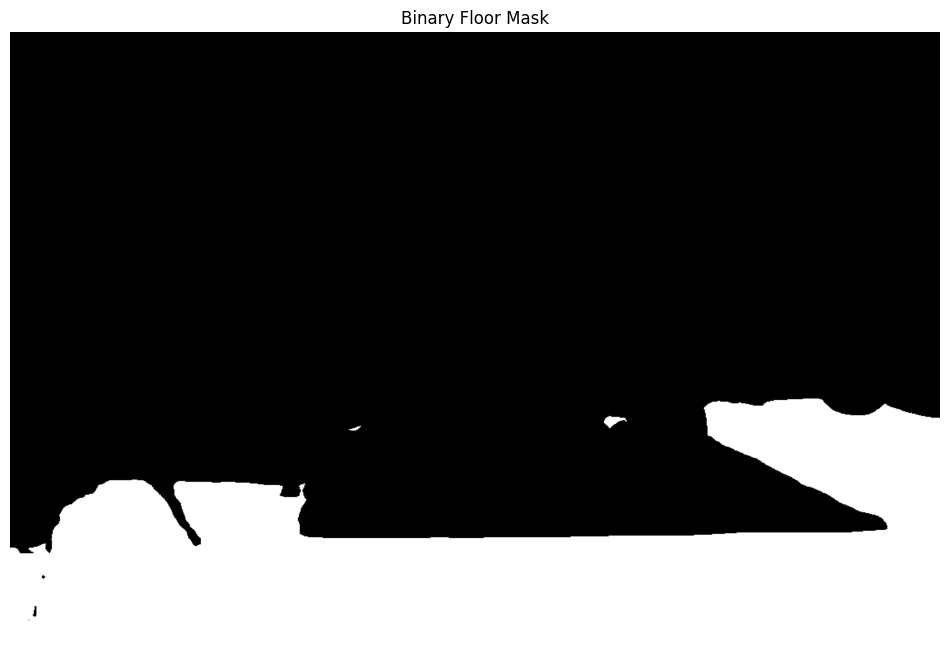

In [ ]:
mask = floor_mask.astype(np.uint8) * 255

plt.figure(figsize=(12,8))
plt.imshow(mask, cmap="gray")
plt.title("Binary Floor Mask")
plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(5632.5), np.float64(3725.5), np.float64(-0.5))

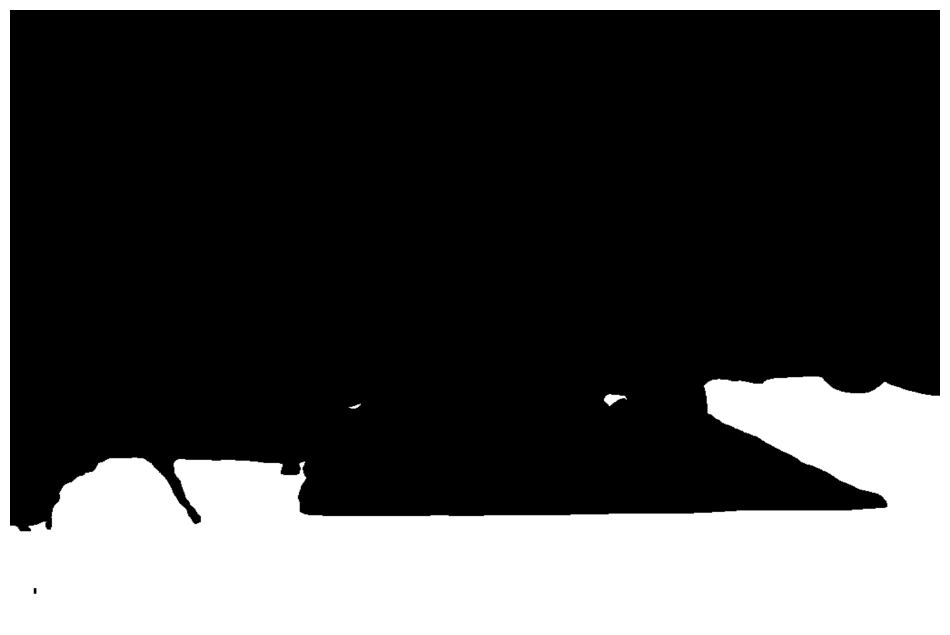

In [ ]:
kernel = np.ones((15,15), np.uint8)

clean = cv2.morphologyEx(
    mask,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(12,8))
plt.imshow(clean, cmap='gray')
plt.axis("off")

In [ ]:
!pip -q install timm
!git clone https://github.com/DepthAnything/Depth-Anything-V2.git
%cd Depth-Anything-V2
!pip -q install -r requirements.txt

Cloning into 'Depth-Anything-V2'...
remote: Enumerating objects: 146, done.
remote: Total 146 (delta 0), reused 0 (delta 0), pack-reused 146 (from 1)
Receiving objects: 100% (146/146), 45.18 MiB | 24.80 MiB/s, done.
Resolving deltas: 100% (45/45), done.
/content/Depth-Anything-V2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 1.3 MB/s eta 0:00:00


In [ ]:
!mkdir checkpoints

!wget -O checkpoints/depth_anything_v2_vits.pth \
https://huggingface.co/depth-anything/Depth-Anything-V2-Small/resolve/main/depth_anything_v2_vits.pth

--2026-08-06 07:30:51--  https://huggingface.co/depth-anything/Depth-Anything-V2-Small/resolve/main/depth_anything_v2_vits.pth
Resolving huggingface.co (huggingface.co)... 3.165.63.83, 3.165.63.112, 3.165.63.125, ...
Connecting to huggingface.co (huggingface.co)|3.165.63.83|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/666b17aaed1ed0f9bf42823e/01950a0198f6ece4acfd924dbc91f9f6bed4b614a222d64ad3c516ba39447464?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27depth_anything_v2_vits.pth%3B+filename%3D%22depth_anything_v2_vits.pth%22%3B&X-Xet-Cas-Uid=public&user_id=public&Expires=1786005051&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjY2YjE3YWFlZDFlZDBmOWJmNDI4MjNlLzAxOTUwYTAxOThmNmVjZTRhY2ZkOTI0ZGJjOTFmOWY2YmVkNGI2MTRhMjIyZDY0YWQzYzUxNmJhMzk0NDc0NjRcXD9yZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSomWC1YZXQtQ2FzLVVpZD1wdWJsaWMmdXNlcl9pZD1wdWJsaWMiLCJDb25kaXRpb24i

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from depth_anything_v2.dpt import DepthAnythingV2

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = DepthAnythingV2(
    encoder='vits',
    features=64,
    out_channels=[48,96,192,384]
)

model.load_state_dict(
    torch.load(
        "checkpoints/depth_anything_v2_vits.pth",
        map_location=DEVICE
    )
)

model = model.to(DEVICE).eval()

print("Depth Anything V2 Loaded!")

Depth Anything V2 Loaded!


In [ ]:
import numpy as np

image = np.array(original_image)

depth = model.infer_image(image)

print(depth.shape)

(3726, 5633)


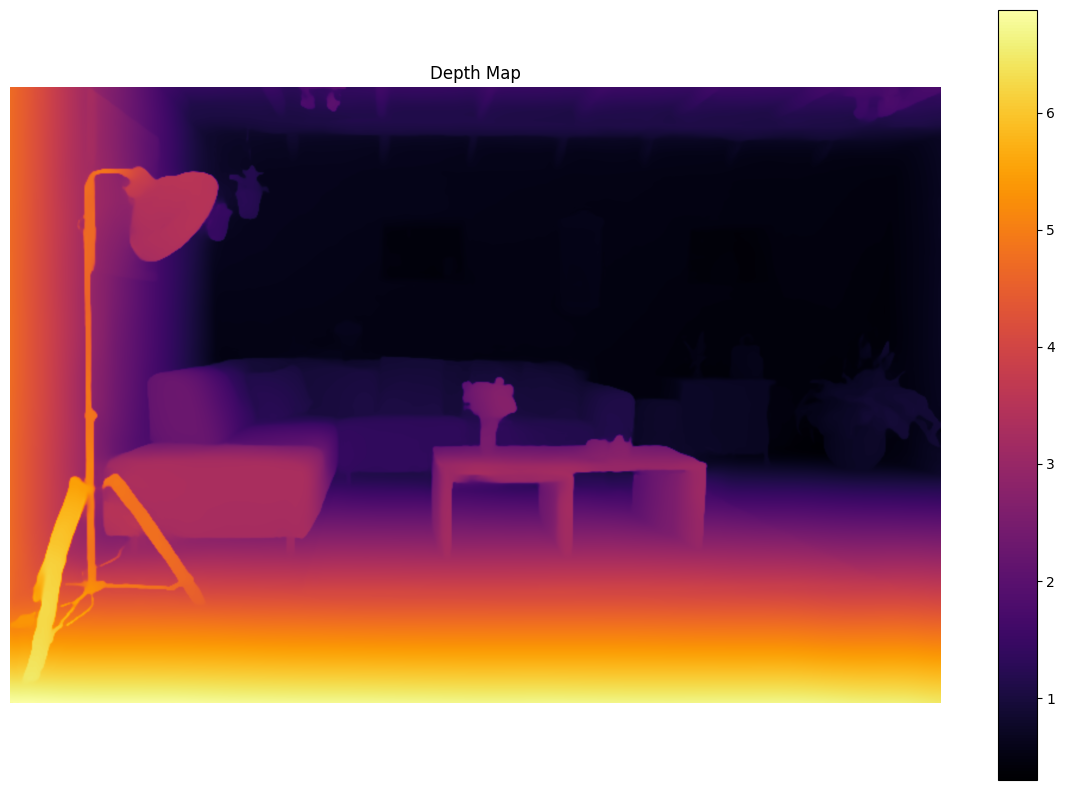

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plt.imshow(depth, cmap="inferno")
plt.colorbar()
plt.title("Depth Map")
plt.axis("off")
plt.show()

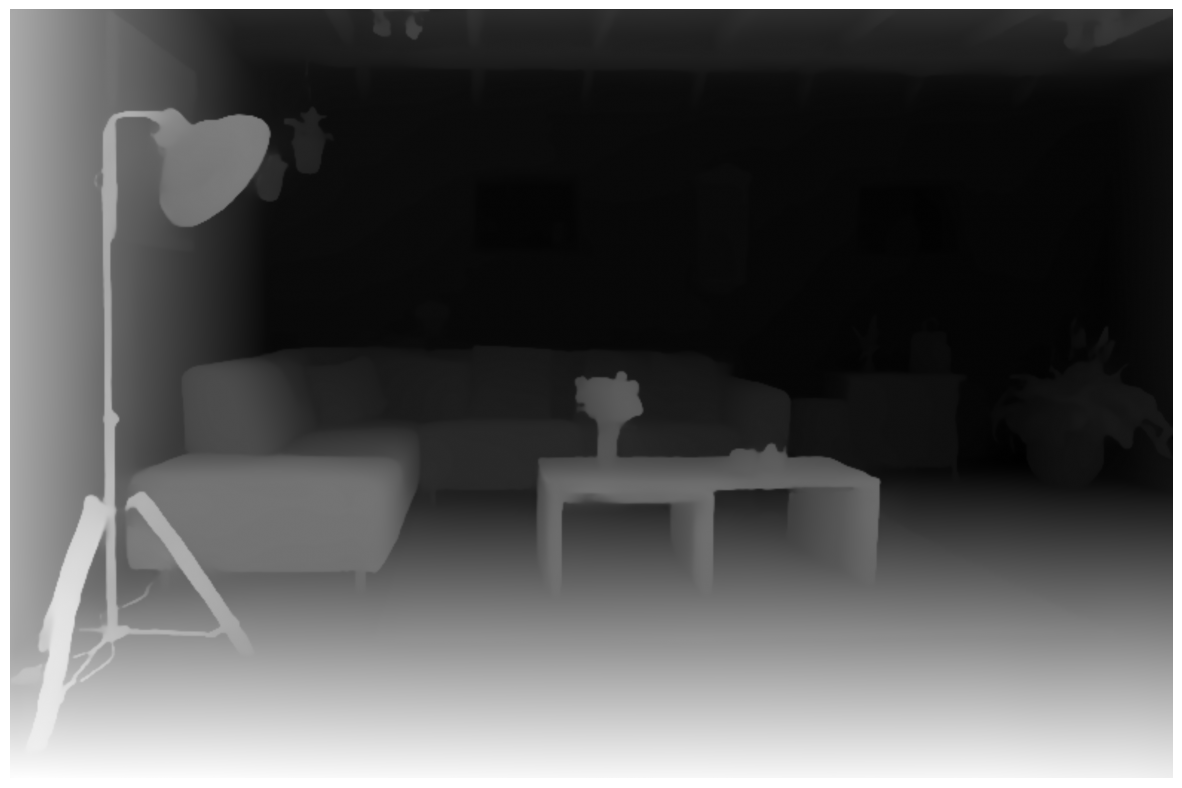

In [ ]:
depth_norm = cv2.normalize(
    depth,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype("uint8")

plt.figure(figsize=(15,10))
plt.imshow(depth_norm, cmap="gray")
plt.axis("off")
plt.show()

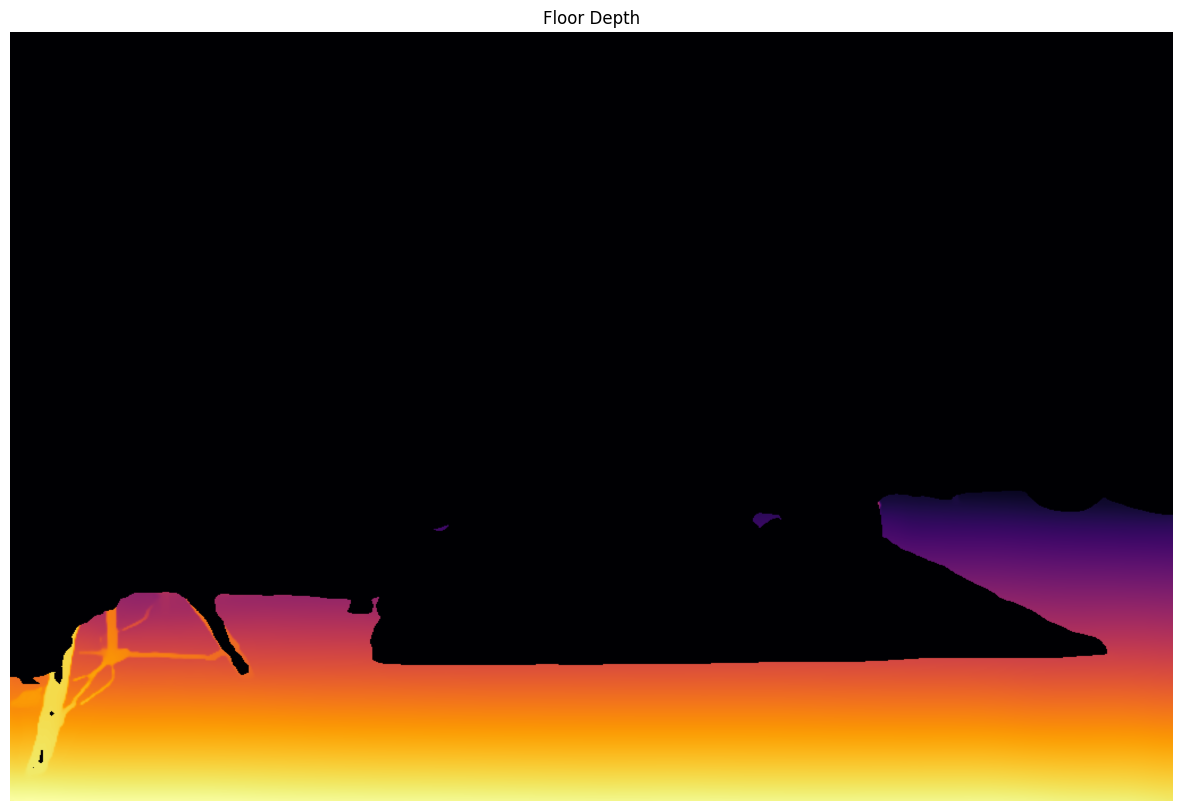

In [ ]:
floor_depth = depth.copy()

floor_depth[~floor_mask] = 0

plt.figure(figsize=(15,10))
plt.imshow(floor_depth, cmap="inferno")
plt.title("Floor Depth")
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

# Floor pixel coordinates
ys, xs = np.where(floor_mask)

# Relative depth values
zs = depth[ys, xs]

# Create Nx3 point cloud
points = np.column_stack((xs, ys, zs))

print("Number of floor points:", len(points))
print(points[:5])

Number of floor points: 4925014
[[4.80300000e+03 2.22300000e+03 4.24116284e-01]
 [4.80400000e+03 2.22300000e+03 4.23855245e-01]
 [4.80500000e+03 2.22300000e+03 4.23582405e-01]
 [4.80600000e+03 2.22300000e+03 4.23254669e-01]
 [4.80700000e+03 2.22300000e+03 4.22926933e-01]]


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Convert boolean mask to uint8
mask = (floor_mask.astype(np.uint8)) * 255

# Remove small holes
kernel = np.ones((15,15), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# Find contours
contours, _ = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,

    cv2.CHAIN_APPROX_NONE
)

largest = max(contours, key=cv2.contourArea)

print("Largest contour area:", cv2.contourArea(largest))

Largest contour area: 4911186.5


Vertices: 6


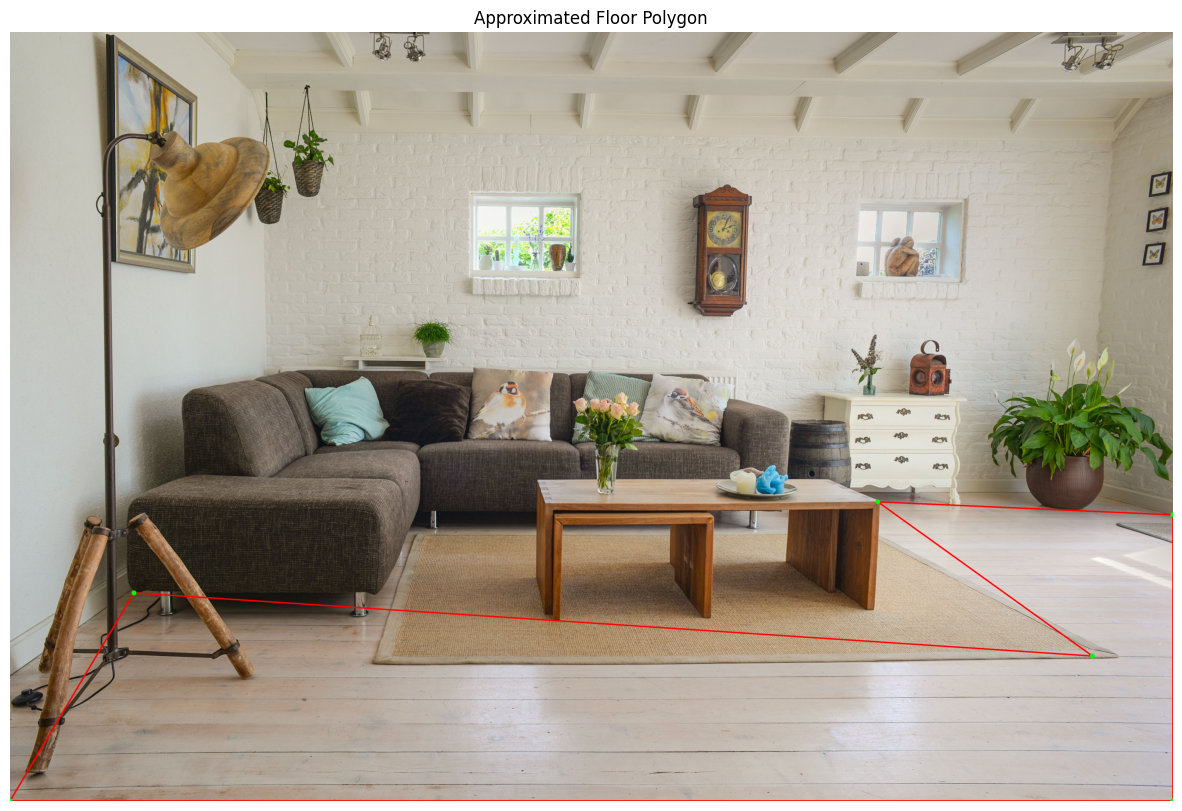

In [ ]:
epsilon = 0.02 * cv2.arcLength(largest, True)

approx = cv2.approxPolyDP(
    largest,
    epsilon,
    True
)

print("Vertices:", len(approx))

img = image.copy()

cv2.drawContours(img, [approx], -1, (255,0,0), 5)

for p in approx:
    x, y = p[0]
    cv2.circle(img, (x, y), 12, (0,255,0), -1)

plt.figure(figsize=(15,10))
plt.imshow(img)
plt.title("Approximated Floor Polygon")
plt.axis("off")
plt.show()

geometry engine

In [ ]:
# Get every boundary point
boundary_points = largest.squeeze()

print("Boundary Points:", boundary_points.shape)
print(boundary_points[:10])

Boundary Points: (18701, 2)
[[4803 2223]
 [4803 2224]
 [4803 2225]
 [4803 2226]
 [4802 2227]
 [4801 2227]
 [4800 2227]
 [4799 2227]
 [4798 2227]
 [4797 2227]]


In [ ]:
boundary_depth = floor_depth[
    boundary_points[:,1],
    boundary_points[:,0]
]

print("Boundary Depth Shape:", boundary_depth.shape)
print("Min Depth:", np.nanmin(boundary_depth))
print("Max Depth:", np.nanmax(boundary_depth))

Boundary Depth Shape: (18701,)
Min Depth: 0.0
Max Depth: 6.878447
